In [6]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt



# 1. CSV-Dateien einlesen (Pfad zu realen und synthetischen Daten anpassen)
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path = "../../data/synthetic_result_data/536_synthetic_train_data.csv"

df_real = pd.read_csv(real_path)
df_syn = pd.read_csv(syn_path)


In [7]:
def visualize_structural_consistency(original: pd.DataFrame,
                                     synthetic: pd.DataFrame,
                                     eps=0.5,
                                     min_samples=5):
    """
    Visualizes structural consistency between original and synthetic datasets:
    - One-hot encodes categorical features.
    - Standardizes numeric features.
    - PCA and t-SNE separately for each dataset.
    - Joint PCA and t-SNE colored by dataset (0=original, 1=synthetic).
    - KMeans and DBSCAN clustering on joint feature space, plotted on PCA.
    """
    # Identify numeric and categorical columns common to both
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    # One-hot encode categorical columns
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    # Standardize numeric features jointly
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Build final feature matrices
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)
    labels_syn  = np.ones(len(X_syn),  dtype=int)
    
    # 1. PCA & t-SNE separately
    for name, X in [('Original', X_orig), ('Synthetic', X_syn)]:
        # PCA
        pca_proj = PCA(n_components=2, random_state=42).fit_transform(X)
        plt.figure()
        plt.scatter(pca_proj[:,0], pca_proj[:,1], alpha=0.6)
        plt.title(f'PCA - {name}')
        
        # t-SNE
        tsne_proj = TSNE(n_components=2, random_state=42).fit_transform(X)
        plt.figure()
        plt.scatter(tsne_proj[:,0], tsne_proj[:,1], alpha=0.6)
        plt.title(f't-SNE - {name}')
    
    # 2. Joint projection
    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])
    
    # Joint PCA
    pca_joint = PCA(n_components=2, random_state=42).fit_transform(X_joint)
    plt.figure()
    plt.scatter(pca_joint[:,0], pca_joint[:,1], c=labels, alpha=0.6)
    plt.title('Joint PCA (0=Orig,1=Synth)')
    
    # Joint t-SNE
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)
    plt.figure()
    plt.scatter(tsne_joint[:,0], tsne_joint[:,1], c=labels, alpha=0.6)
    plt.title('Joint t-SNE (0=Orig,1=Synth)')
    
    # 3. Clustering on joint feature space
    km = KMeans(n_clusters=2, random_state=42).fit(X_joint)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_joint)
    
    # Plot KMeans clusters on PCA
    plt.figure()
    plt.scatter(pca_joint[:,0], pca_joint[:,1], c=km.labels_, alpha=0.6)
    plt.title('KMeans clusters on Joint PCA')
    
    # Plot DBSCAN clusters on PCA
    plt.figure()
    plt.scatter(pca_joint[:,0], pca_joint[:,1], c=db.labels_, alpha=0.6)
    plt.title('DBSCAN clusters on Joint PCA')



In [ ]:
def compute_structural_similarity_score(original: pd.DataFrame,
                                        synthetic: pd.DataFrame,
                                        eps=0.5,
                                        min_samples=5,
                                        weights=None):
    """
    Computes a universal structural similarity score ∈ [0,1], where 1 is best.
    Integrates:
      - Cluster Purity (KMeans & DBSCAN)
      - Adjusted Rand Index (KMeans & DBSCAN)
      - Cosine Similarity of global mean feature vectors
    Each subscore ∈ [0,1]; final score is the average.
    """
    # Preprocessing: one-hot encode categorical + standardize numeric
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler().fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Feature matrices
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels = np.concatenate([np.zeros(len(X_orig)), np.ones(len(X_syn))])
    X_joint = np.vstack([X_orig, X_syn])
    
    # 1. Cluster Purity Subscores
    def purity_subscore(cl_labels):
        subs = []
        for c in np.unique(cl_labels):
            mask = (cl_labels == c)
            counts = np.bincount(labels[mask].astype(int), minlength=2)
            if counts.sum() == 0: continue
            purity = counts.max() / counts.sum()
            # Map purity 0.5->1.0, purity 1.0->0.0
            subs.append(max(0, 1 - abs(purity - 0.5) / 0.5))
        return np.mean(subs) if subs else 0.0
    
    km_labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_joint)
    db_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_joint)
    s_purity_km = purity_subscore(km_labels)
    s_purity_db = purity_subscore(db_labels)
    
    # 2. ARI Subscores
    s_ari_km = 1 - abs(adjusted_rand_score(labels, km_labels))
    s_ari_db = 1 - abs(adjusted_rand_score(labels, db_labels))
    
    # 3. Cosine Similarity Subscore
    vec_orig = X_orig.mean(axis=0).reshape(1, -1)
    vec_syn  = X_syn.mean(axis=0).reshape(1, -1)
    cos_val = cosine_similarity(vec_orig, vec_syn)[0, 0]
    s_cos = (cos_val + 1) / 2  # map [-1,1] to [0,1]
    
    # Default equal weights across 5 subscores
    if weights is None:
        weights = {
            'purity_km': 0.1,
            'purity_db': 0.1,
            'ARI_km':    0.1,
            'ARI_db':    0.1,
            'cosine':    0.5
        } 
    
    # Combine
    structural_score = (
        weights['purity_km'] * s_purity_km +
        weights['purity_db'] * s_purity_db +
        weights['ARI_km']    * s_ari_km +
        weights['ARI_db']    * s_ari_db +
        weights['cosine']    * s_cos
    )
    
    return round(float(structural_score), 4)



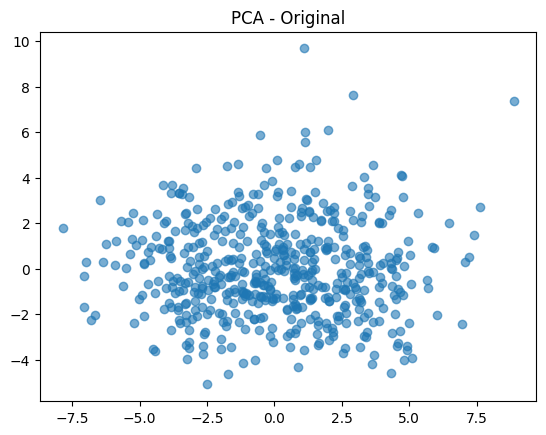

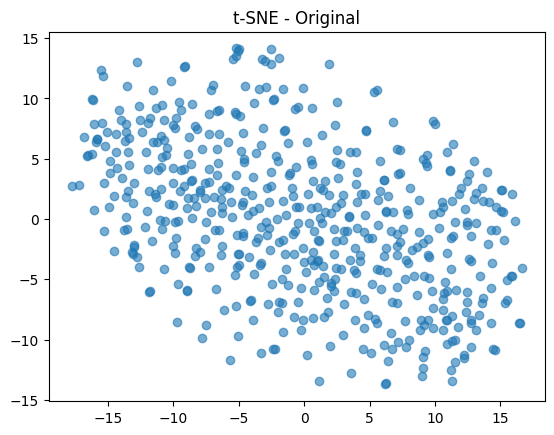

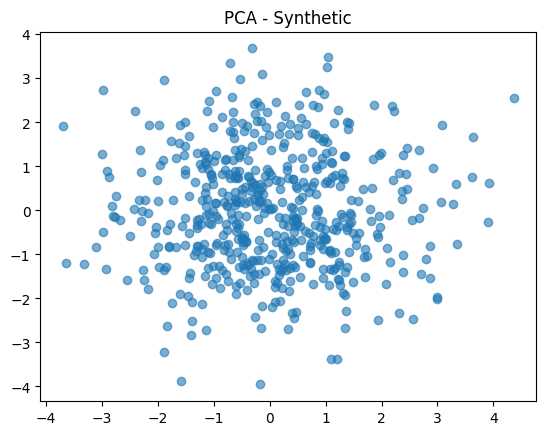

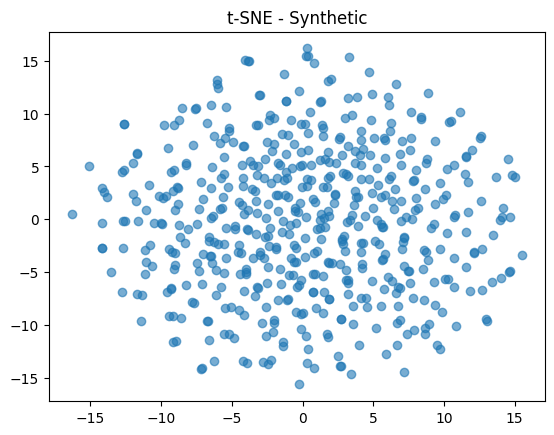

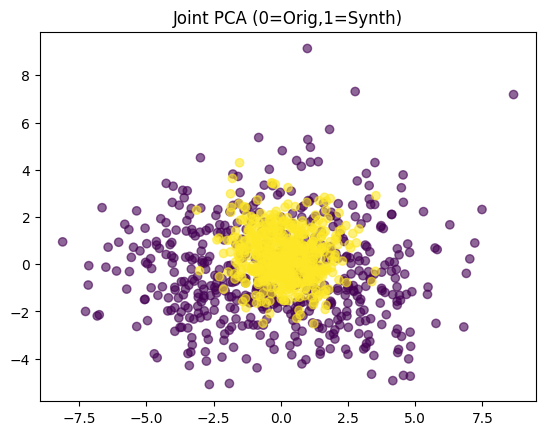

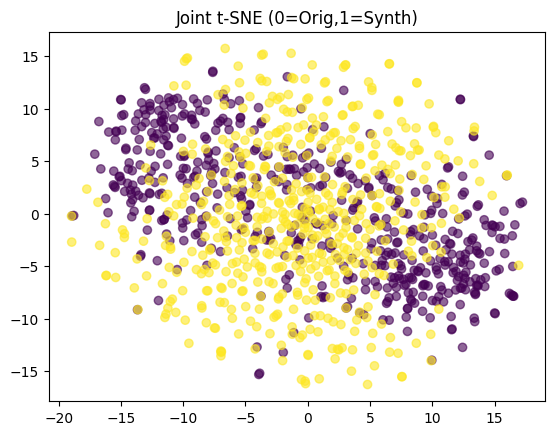

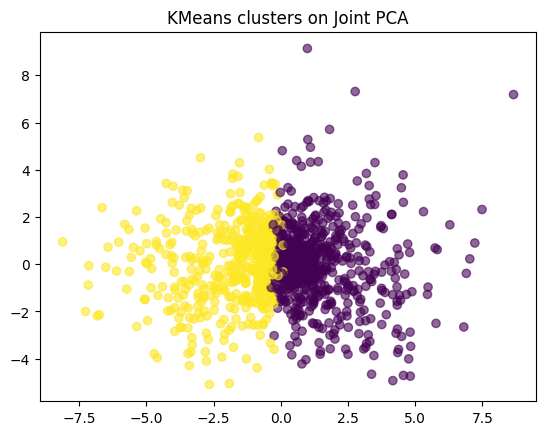

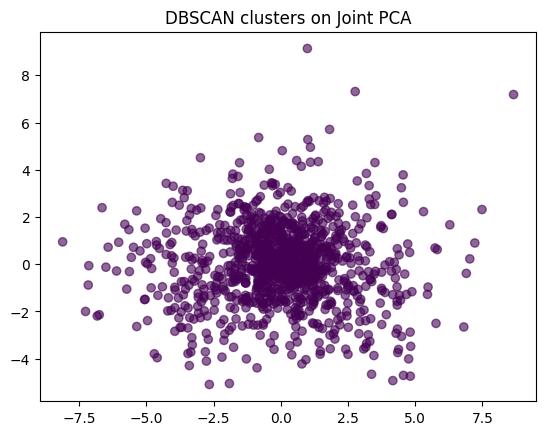

In [9]:
visualize_structural_consistency(df_real, df_syn)

In [10]:

sim_score = compute_structural_similarity_score(df_real, df_syn)
print("Structure Consistency Score:", sim_score)

Structure Consistency Score: 0.7913
